In [29]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
from collections import defaultdict
from typing import Any, Callable, Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pmdarima as pm
import scipy.stats as sps
import seaborn as sns
import statsmodels
import statsmodels.api as sm
import sys
import torch
import tsfresh
from catboost import CatBoostRegressor
from IPython.display import HTML, clear_output, display
from prophet import Prophet
from pylab import rcParams
from sktime.split import ExpandingWindowSplitter
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
)
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from statsforecast import models as sf_models
from statsforecast.models import (
    SimpleExponentialSmoothing,
    SimpleExponentialSmoothingOptimized,
)
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt, SimpleExpSmoothing
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from torch import nn
from torch.utils.data import DataLoader, Dataset, random_split
from tqdm import tqdm
from tqdm.auto import tqdm as auto_tqdm
from tsfresh import extract_features, select_features
from tsfresh.feature_extraction import settings
from tsfresh.utilities.dataframe_functions import impute, roll_time_series

# Visualization setup
sns.set(font_scale=1.3, palette="Set2")
rcParams['figure.figsize'] = 15, 7
%matplotlib inline
from utils.vis import plot_dist_matrix
from utils.misc import save_dict_as_json
from utils.data_transform import take_diff
from utils.clusterization import build_coint_mat, cluster_from_distance_matrix, get_linear_clusters
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from utils.models import ClusterModel
from utils.vis import plot_error_matrix, plot_model_pred, calc_average_error, plot_delta_matrix_anchored
from utils.interface import cross_validate_model, calc_avg_error, build_error_matrix, build_short_error_matrix

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Уберем пока помидоры и огурцы так как для них у нас своя модель

In [2]:
df = pd.read_csv("/home/danilach/mipt-stats/SberTs/Data/comb_df_v1.csv", index_col=0)
df.index = pd.to_datetime(df.index)
df = df.drop(
    columns=[
        "Огурцы тепличные, руб./кг",
        "Томаты тепличные, руб./кг",
    ]
)

# Clusterization and ClusterModel

    `get_linear_clusters`

    
    """
    Hierarchical clustering for multivariate time series.

    Parameters
    df : pd.DataFrame
        Datetime-indexed multivariate time series (columns = series).
    dist_method : str
        One of: "correlation", "Engle-Granger", "Johansen"
        For cointegration-based methods, this calls build_coint_mat(df, test=dist_method).
    linkage_method : str
        Linkage method for scipy.cluster.hierarchy.linkage (e.g., "ward","single","average","complete").
    threshold : float
        Distance threshold used in fcluster(..., criterion="distance").
    visualize : bool, default False
        If True, plot dendrogram and draw a horizontal line at `threshold`.
    diff_order : int
        Optional differencing order applied to df via take_diff(df, diff_order).
    distance_scaling : str
        One of {"none","minmax","minmax_0_100","sqrt","log1p"}.
        - "none": use raw distances as produced
        - "minmax": rescale to [0,1]
        - "sqrt": sqrt transform (preserves ordering)
        - "log1p": log(1 + x) transform (compress large values)
    Returns
    clusters : dict
        Mapping {series_name: cluster_label}, where cluster_label is an integer from fcluster.
    """

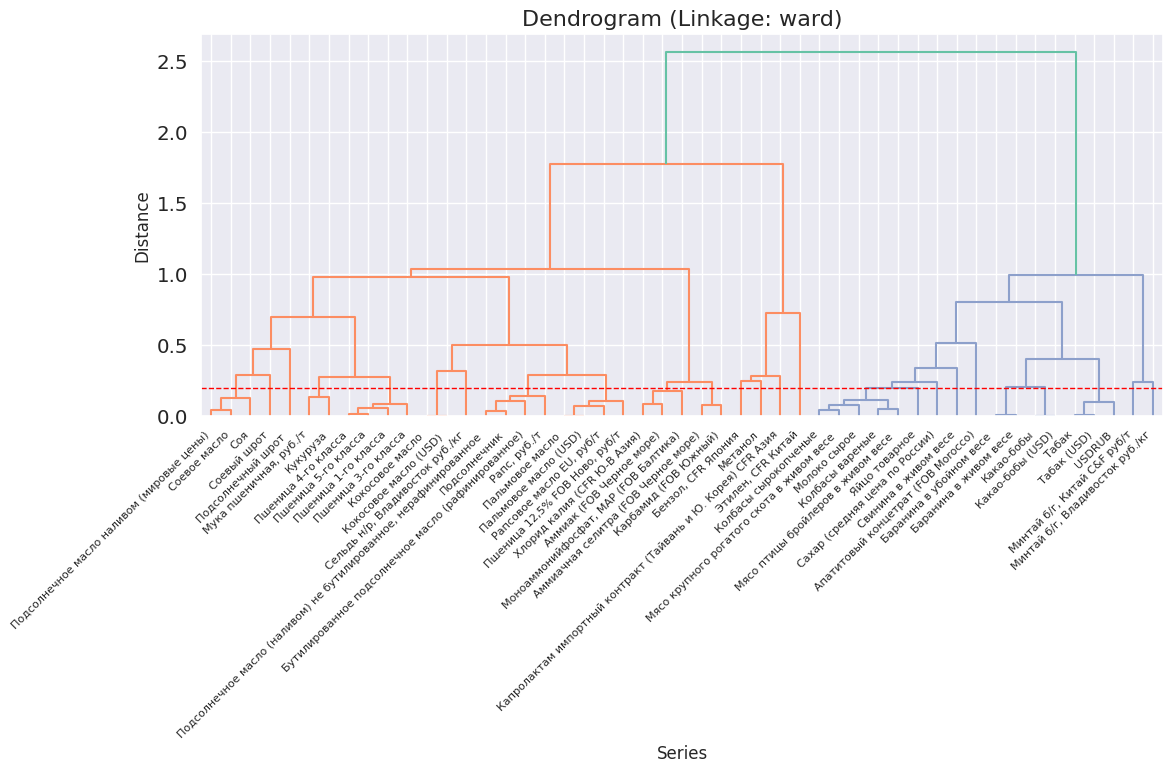

In [3]:
clusters = get_linear_clusters(df, "correlation", "ward", 0.2, visualize=True)

### Принцип прогнозирования

In [27]:
clusters = get_linear_clusters(df, "correlation", "ward", 0.2)
clusters

{'USDRUB': 3,
 'Кукуруза': 21,
 'Молоко сырое': 6,
 'Мясо птицы бройлеров в живом весе ': 6,
 'Мясо крупного рогатого скота в живом весе ': 6,
 'Подсолнечник': 17,
 'Пшеница 1-го класса': 20,
 'Пшеница 3-го класса': 20,
 'Пшеница 5-го класса': 20,
 'Сахар (средняя цена по России)': 7,
 'Свинина в живом весе': 8,
 'Соевое масло': 22,
 'Соевый шрот': 23,
 'Соя': 22,
 'Яйцо товарное': 6,
 'Подсолнечное масло наливом (мировые цены)': 22,
 'Бутилированное подсолнечное масло (рафинированное)': 17,
 'Подсолнечный шрот ': 24,
 'Колбасы сырокопченые': 6,
 'Баранина в живом весе': 5,
 'Баранина в убойном весе ': 5,
 'Какао-бобы (USD)': 4,
 'Какао-бобы': 4,
 'Подсолнечное масло (наливом) не бутилированное, нерафинированное ': 17,
 'Кокосовое масло (USD) ': 18,
 'Кокосовое масло ': 18,
 'Пальмовое масло (USD)': 16,
 'Пальмовое масло ': 16,
 'Табак (USD)': 3,
 'Табак': 3,
 'Пшеница 4-го класса': 20,
 'Минтай б/г, Владивосток руб./кг': 1,
 'Сельдь н/р, Владивосток руб./кг': 19,
 'Колбасы вареные': 6

`2, 3, 4` ряды находятся в одном кластере, проводя **conditioning** на 3 ряде ма меняем предсказание для всех рядов 

Для `3` ряда - линейная экстраполяция, для `2, 4` - тоже тк они в одном кластере с `3`, а для `5` - наивный пргноз

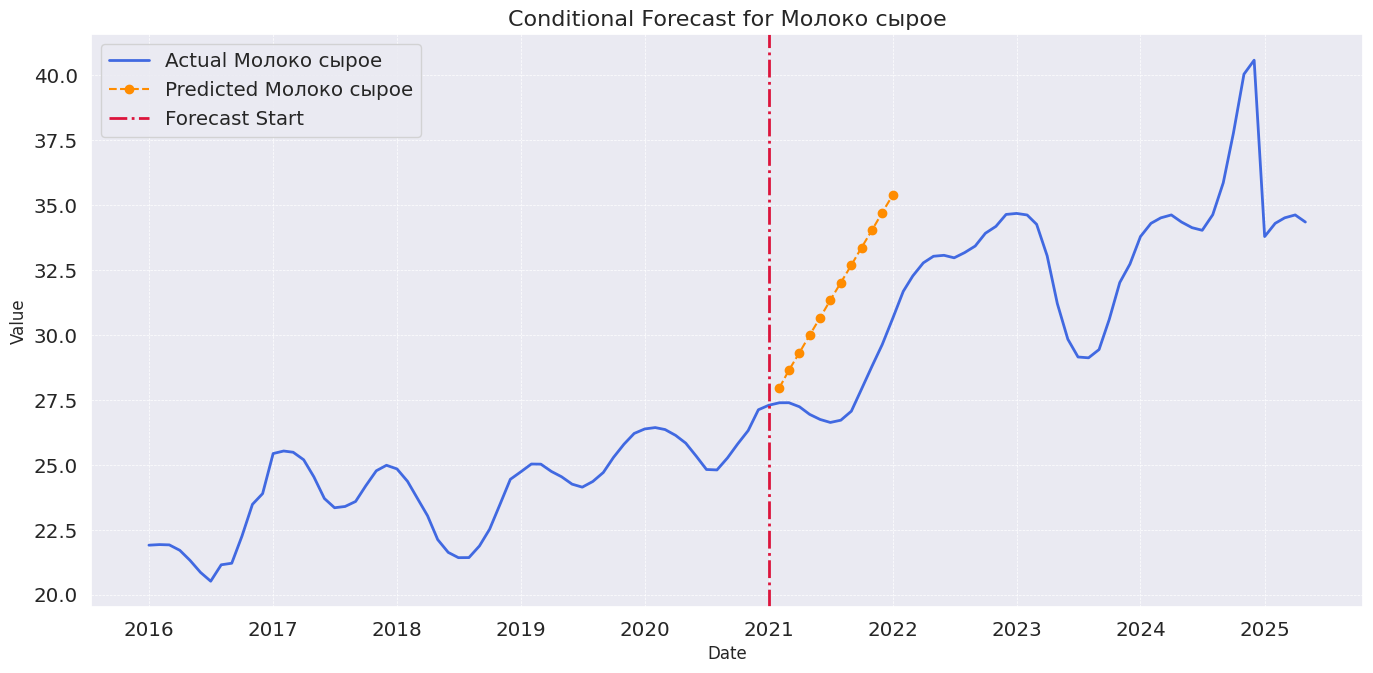

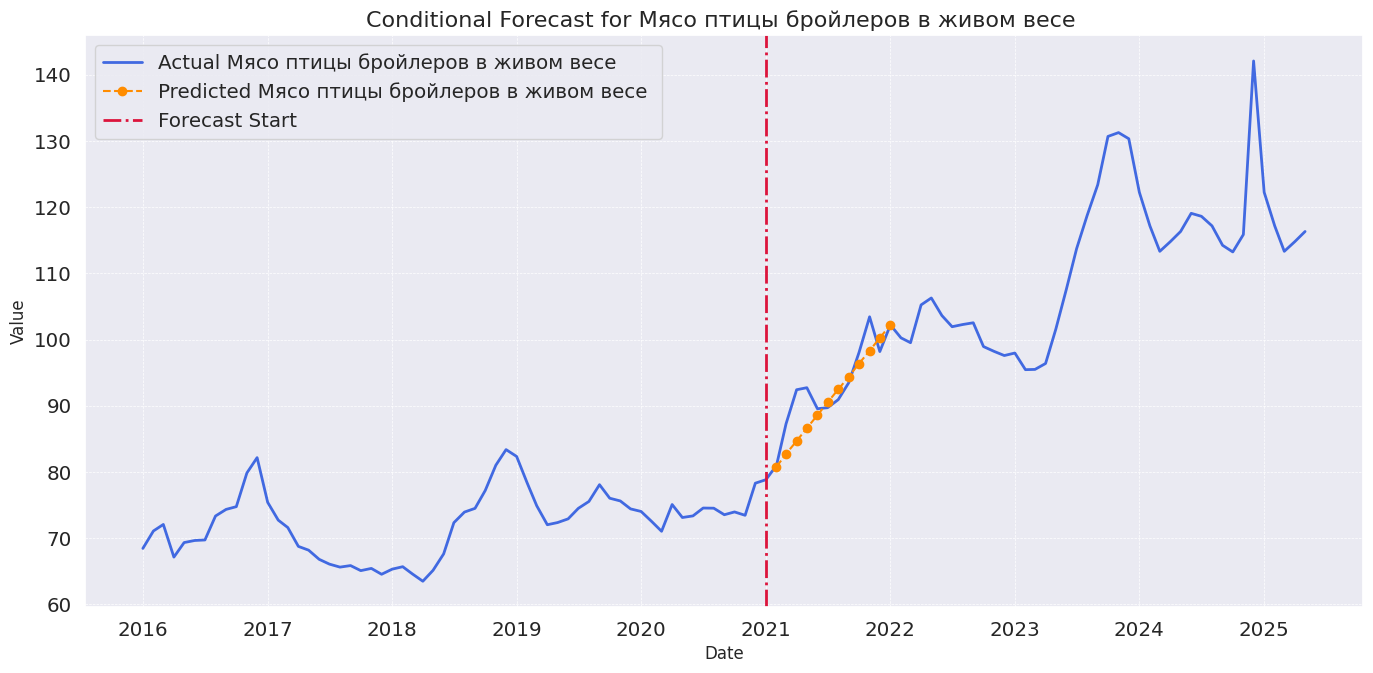

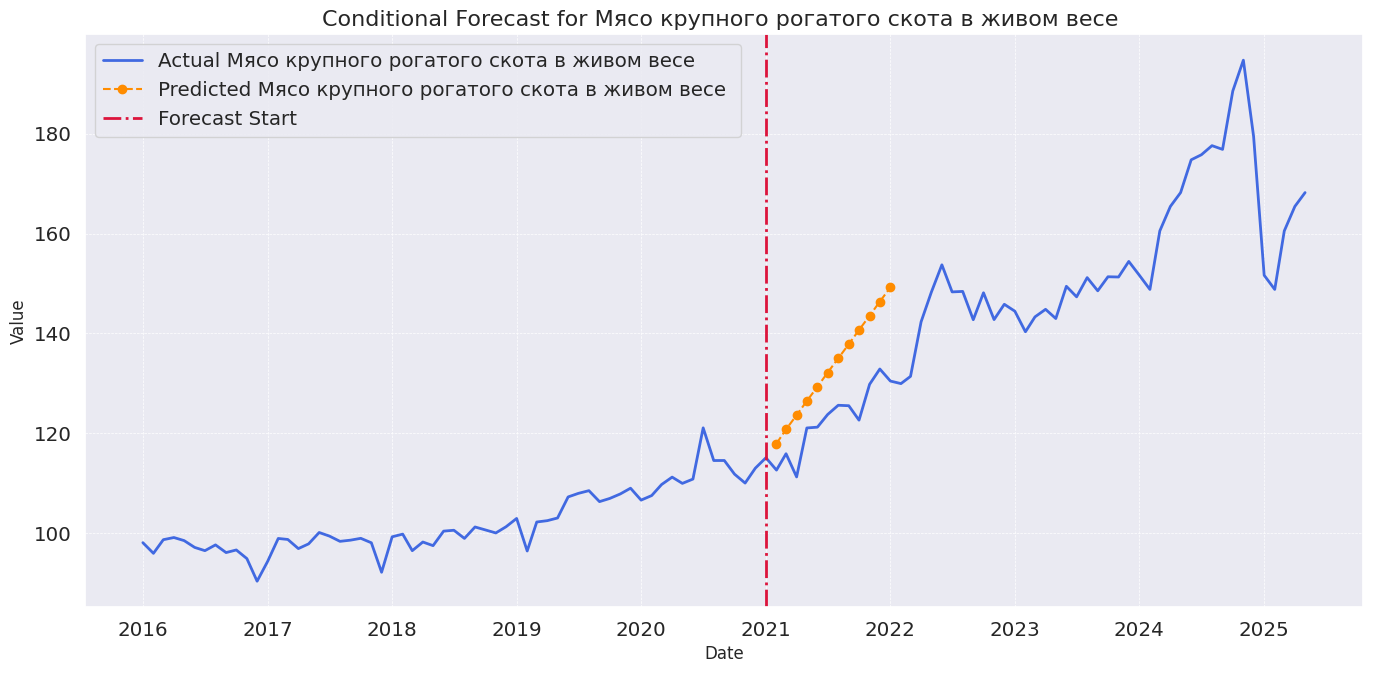

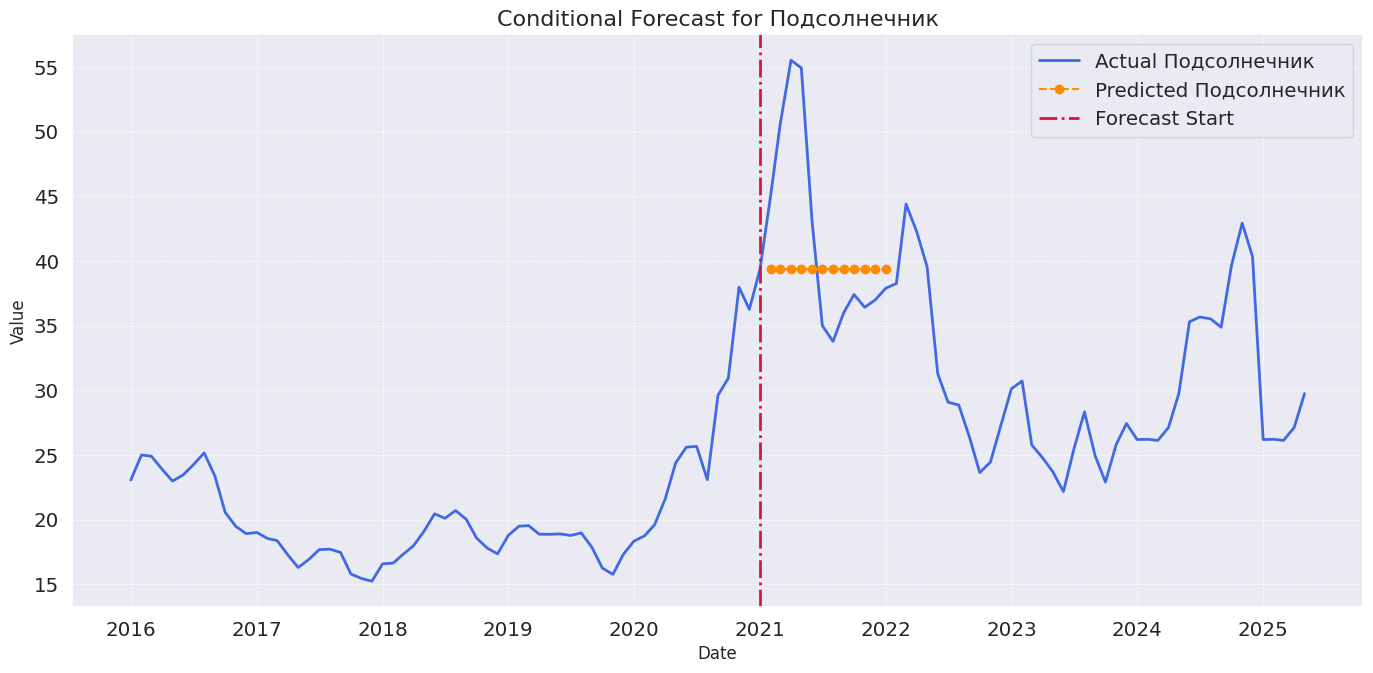

In [28]:
plot_model_pred(
    model_class=ClusterModel,
    df=df[df.columns[2:6]],
    model_params={"clusters": clusters},
    conditioning_col=df.columns[3],
    horizon=12,
    cutoff_date="2021-01-01",
)

### Матрицы ошибок

Посмотрим только на ненаивные прогнозы, за которые `ClusterModel` и ответственна

12.19%


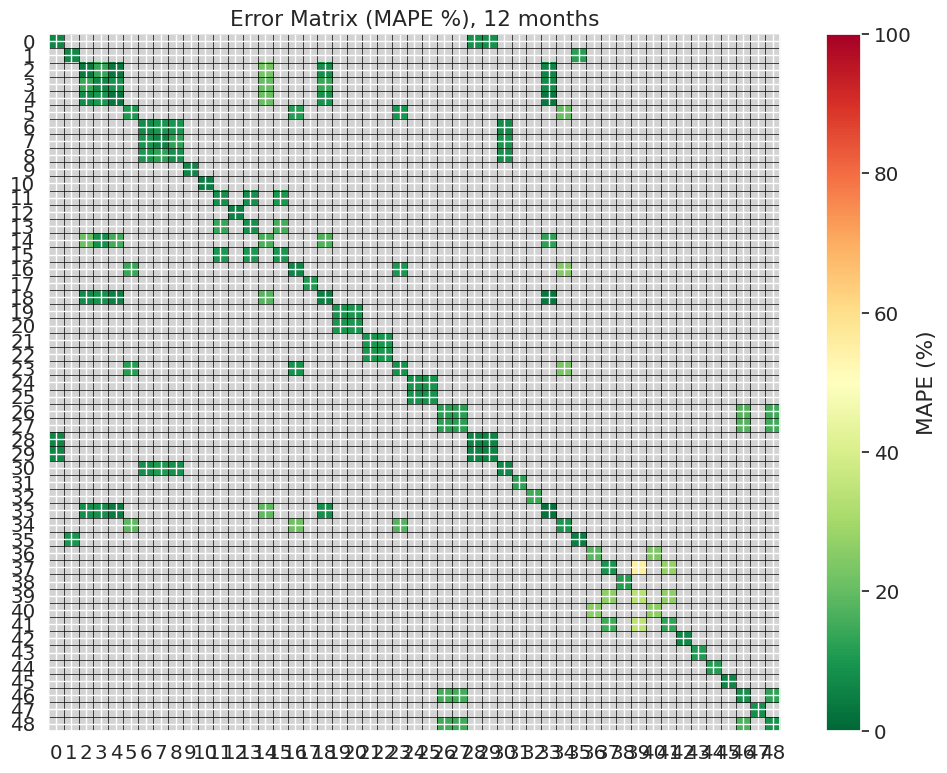

In [9]:
matrix_params = {
    "model_class": ClusterModel,
    "df": df,
    "horizon": 12,
    "stride": 12,
    "start_window": 60,
    "model_params": {"clusters": clusters, "predict_outside_cluster": False},
}

naive_model_matrices = {}

clust_matrix = build_error_matrix(**matrix_params)
mape = calc_average_error(clust_matrix)
plot_error_matrix(clust_matrix, title=f"Error Matrix (MAPE %), 12 months")

Тоже самое с `predict_outside_cluster = True`

16.80%


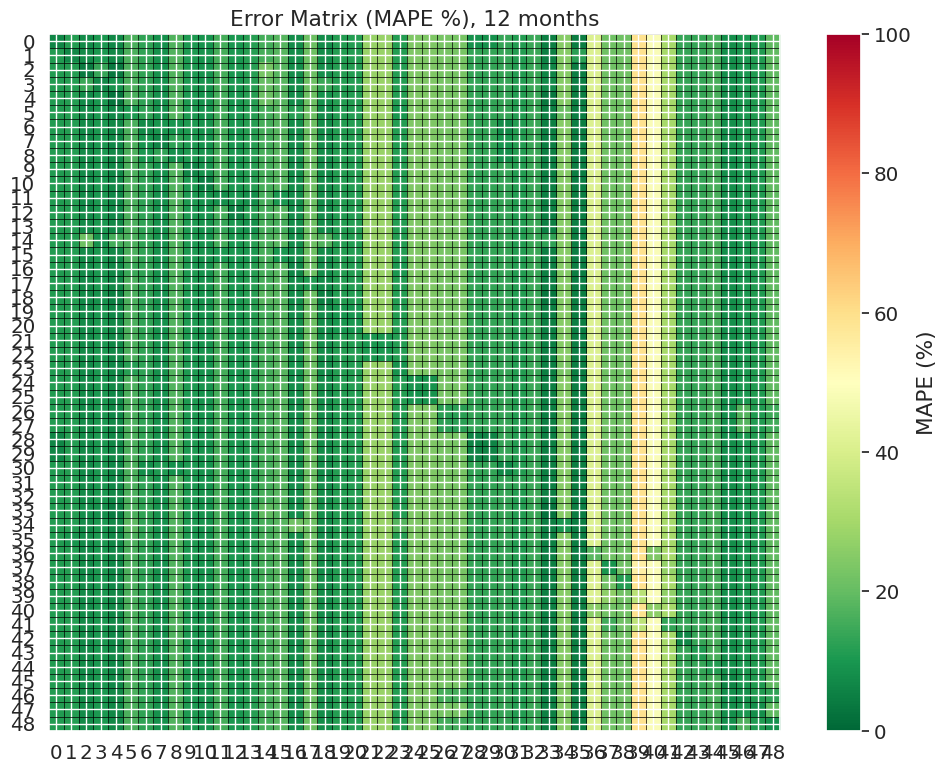

In [8]:
matrix_params = {
    "model_class": ClusterModel,
    "df": df,
    "horizon": 12,
    "stride": 12,
    "start_window": 60,
    "model_params": {"clusters": clusters, "predict_outside_cluster": True},
}

naive_model_matrices = {}

clust_matrix = build_error_matrix(**matrix_params)
mape = calc_average_error(clust_matrix)
plot_error_matrix(clust_matrix, title=f"Error Matrix (MAPE %), 12 months")

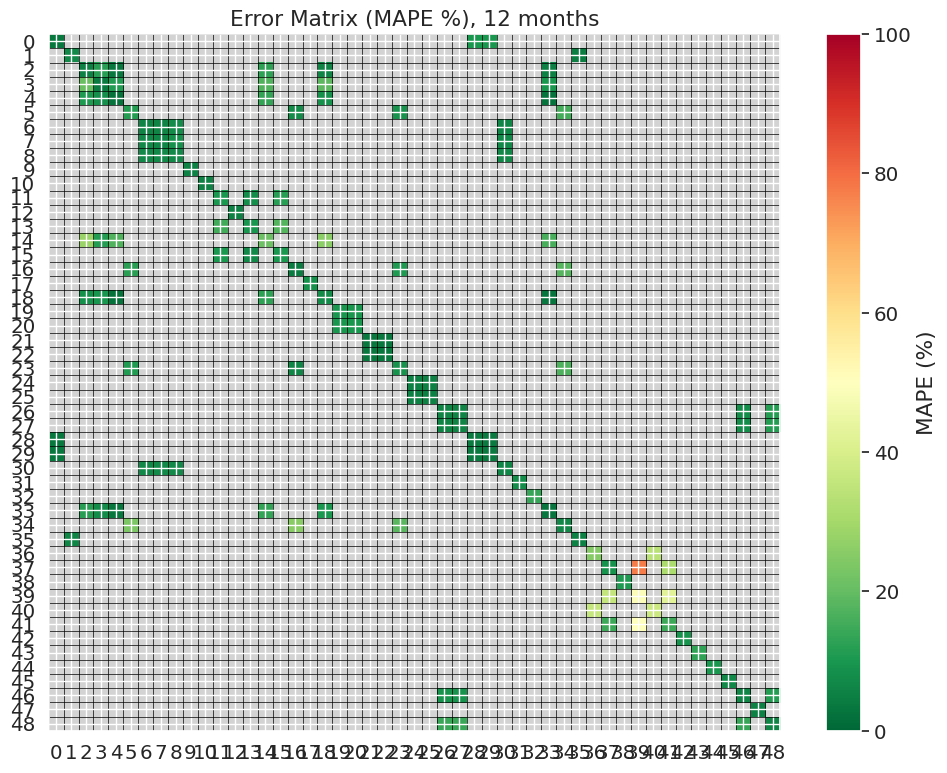

In [ ]:
# plot_error_matrix(clust_matrix, title=f"Error Matrix (MAPE %), 12 months")

### Разные значений `threshold`

In [20]:
threshold_list = [0, 0.2, 0.5, 1, 2]

9.71%


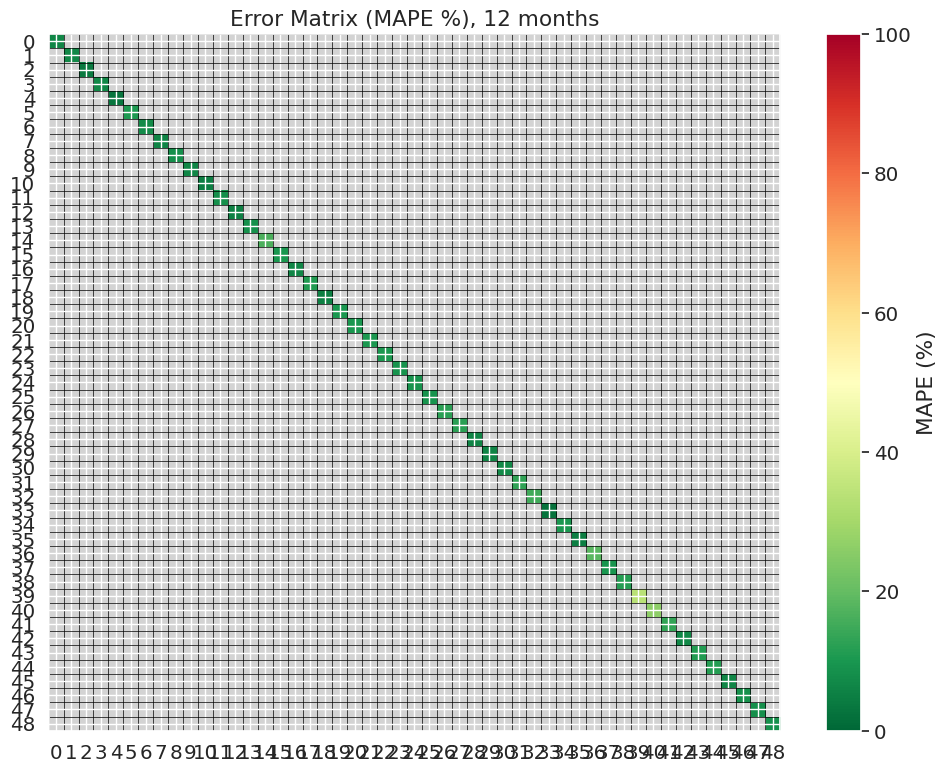

12.19%


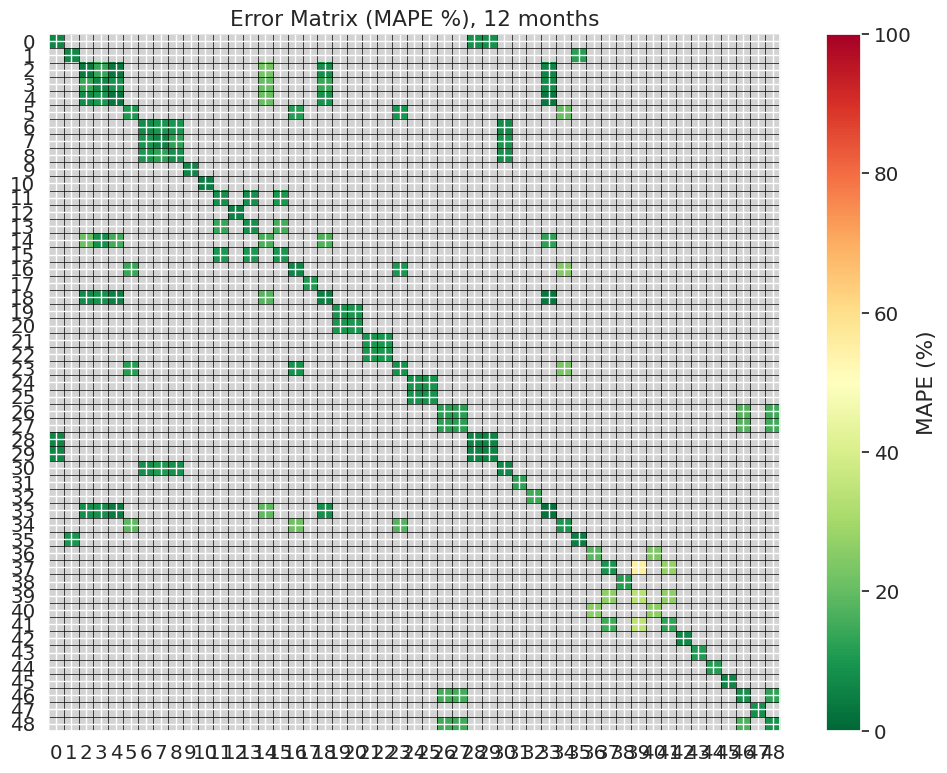

14.79%


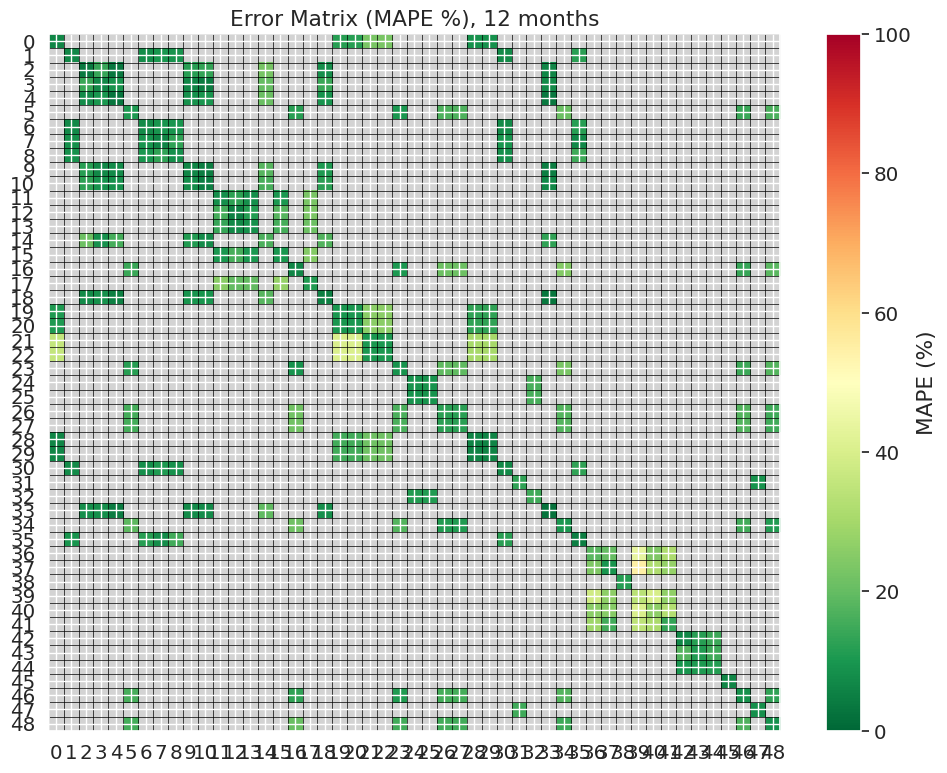

17.28%


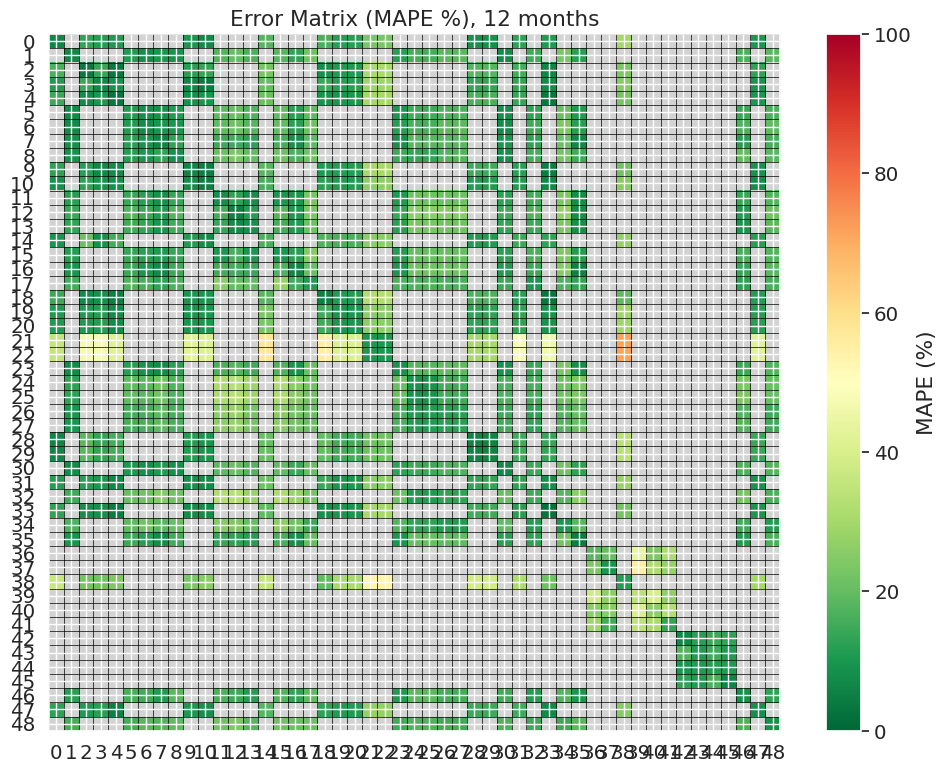

22.17%


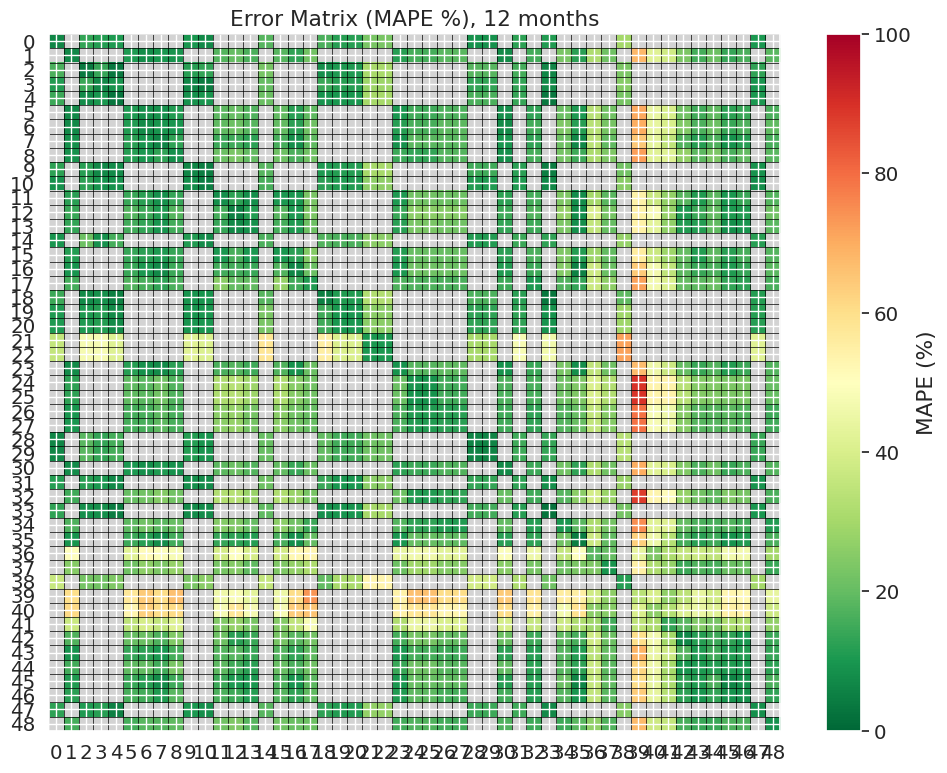

In [21]:
for threshold in threshold_list:
    clusters = get_linear_clusters(df, "correlation", "ward", threshold)
    matrix_params = {
        "model_class": ClusterModel,
        "df": df,
        "horizon": 12,
        "stride": 12,
        "start_window": 60,
        "model_params": {"clusters": clusters, "predict_outside_cluster": False},
    }

    naive_model_matrices = {}

    clust_matrix = build_error_matrix(**matrix_params)
    mape = calc_average_error(clust_matrix)
    plot_error_matrix(clust_matrix, title=f"Error Matrix (MAPE %), 12 months")

С ростом `threshold` растёт как число рядов которые мы предсказываем (т.к число кластерова уменьшается) но также падает и качество (т.к. качество кластеров тоже падает)

### Улучшение по сравнение с тем что было

До этого модель представляла из себя эту же модель при фиксированном `threshold=0` - кластер из 1 ряда, посмотрим какое улучшение показала новая кластеризация

In [ ]:
threshold_grid = np.linspace(0, 1, 10)
matrix_params = {
        "model_class": ClusterModel,
        "df": df,
        "horizon": 12,
        "stride": 12,
        "start_window": 60,
        "model_params": {"clusters": clusters, "predict_outside_cluster": True},  # Set to True
    }

### Correlation-based clusters

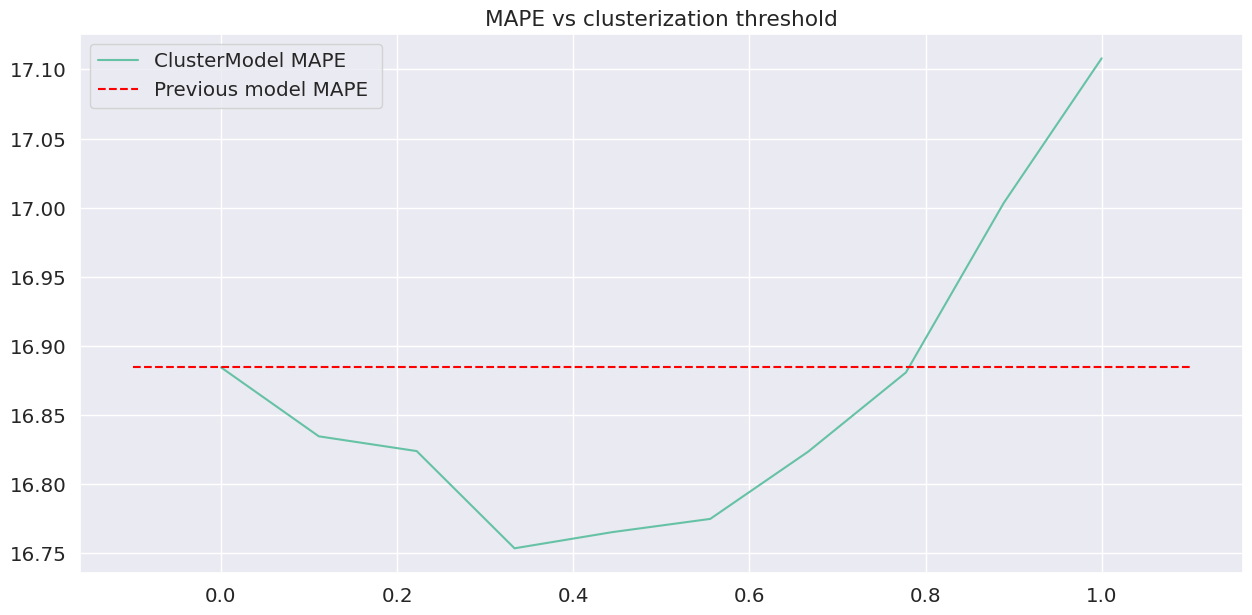

In [ ]:
mape_list = []
for threshold in threshold_grid:
    clusters = get_linear_clusters(df, "correlation", "ward", threshold, diff_order=1)
    matrix_params["model_params"]["clusters"] = clusters
    clust_matrix = build_error_matrix(**matrix_params)
    mape_list.append(np.mean(clust_matrix))

plt.plot(threshold_grid, mape_list, label="ClusterModel MAPE")
plt.hlines(
    mape_list[0],
    threshold_grid[0] - 0.1,
    threshold_grid[-1] + 0.1,
    colors="red",
    linestyles="--",
    label="Previous model MAPE ",
)
plt.title("MAPE vs clusterization threshold")
plt.legend();

Другие параметры

In [ ]:
mape_list = []
for threshold in threshold_grid:
    clusters = get_linear_clusters(df, "correlation", "complete", threshold, diff_order=0)
    matrix_params["model_params"]["clusters"] = clusters
    clust_matrix = build_error_matrix(**matrix_params)
    mape_list.append(np.mean(clust_matrix))

plt.plot(threshold_grid, mape_list, label="ClusterModel MAPE")
plt.hlines(
    mape_list[0],
    threshold_grid[0] - 0.1,
    threshold_grid[-1] + 0.1,
    colors="red",
    linestyles="--",
    label="Previous model MAPE ",
)
plt.title("MAPE vs clusterization threshold")
plt.legend();

Tradeoff между размером и качеством кластеров

### Cointegration-Based clusters (Engle-Granger test)

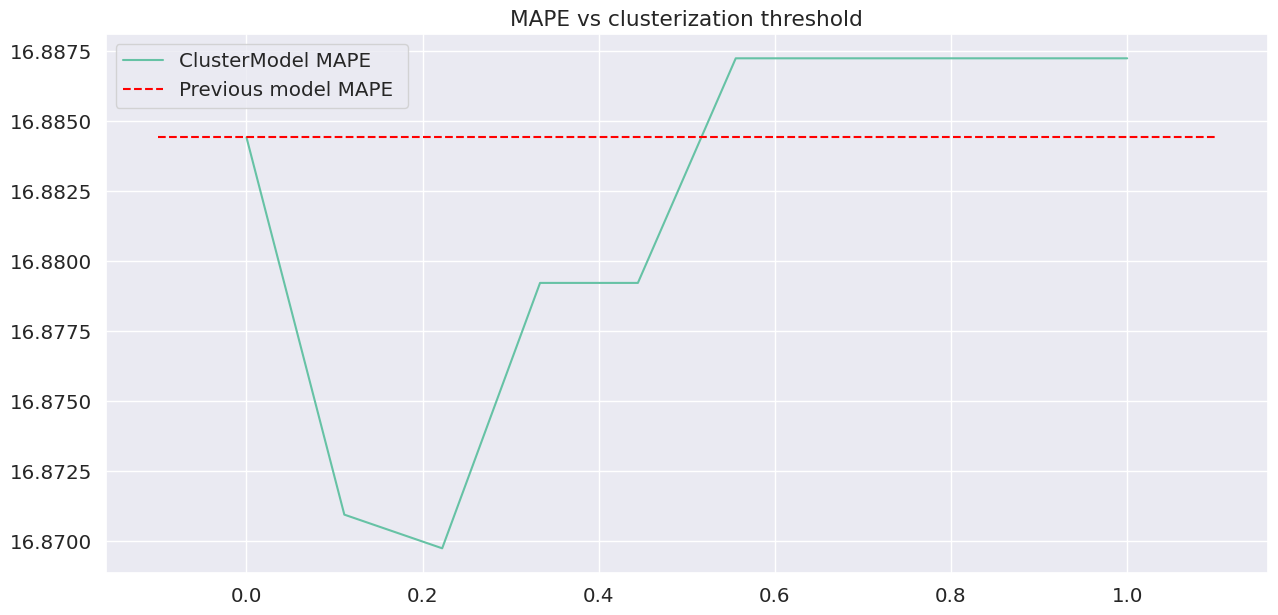

In [51]:
mape_list = []
for threshold in threshold_grid:
    clusters = get_linear_clusters(df, "Engle-Granger", "ward", threshold)
    matrix_params["model_params"]["clusters"] = clusters
    clust_matrix = build_error_matrix(**matrix_params)
    mape_list.append(np.mean(clust_matrix))

plt.plot(threshold_grid, mape_list, label="ClusterModel MAPE")
plt.hlines(
    mape_list[0],
    threshold_grid[0] - 0.1,
    threshold_grid[-1] + 0.1,
    colors="red",
    linestyles="--",
    label="Previous model MAPE ",
)
plt.title("MAPE vs clusterization threshold")
plt.legend()